<a href="https://colab.research.google.com/github/Keke0603/Applied-AI/blob/main/Rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,282 (8.91 KB)

 Trainable params: 2,282 (8.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5571 - loss: 1.2321 - val_accuracy: 0.7059 - val_loss: 0.7771
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6849 - loss: 0.8741 - val_accuracy: 0.7235 - val_loss: 0.7332
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7117 - loss: 0.7998 - val_accuracy: 0.7551 - val_loss: 0.6578
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7260 - loss: 0.7652 - val_accuracy: 0.7619 - val_loss: 0.6448
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7430 - loss: 0.7302 - val_accuracy: 0.7708 - val_loss: 0.6217
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7508 - loss: 0.7125 - val_accuracy: 0.7831 - val_loss: 0.6064
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7644 - loss: 0.6846 - val_accuracy: 0.7900 - val_loss: 0.5939
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7695 - loss: 0.6794 - val_accuracy: 0

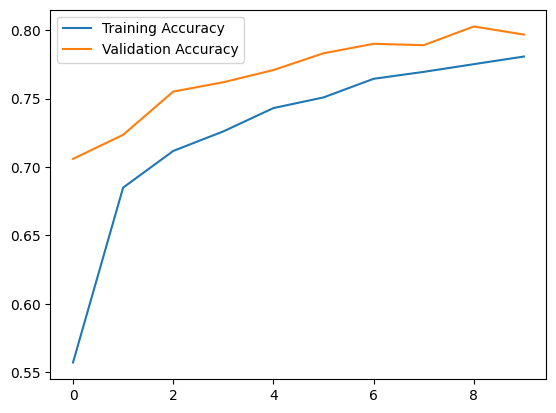

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7947 - loss: 0.5759
Test Accuracy: 79.4700026512146 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
F1 Score: 0.7895787437676356
Confusion Matrix:
 [[788   1  14  65  10   3  99   0  20   0]
 [  6 931  13  37   3   0   8   0   1   1]
 [ 13   0 690  11 182   0  87   0  17   0]
 [ 43   8   7 840  35   2  55   2   5   3]
 [  0   0 119 100 709   0  65   0   4   3]
 [  0   0   0   0   0 912   0  46  10  32]
 [205   2 212  57 171   0 331   0  22   0]
 [  0   0   0   0   0  27   0 868   0 105]
 [  0   2  12  10  11  12  18   4 930   1]
 [  0   0   0   1   0  11   0  39   1 948]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, f1_score

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape: (28,28) → sequence of 28 steps with 28 features
# (RNN expects 3D input: samples, timesteps, features)

# Model
model = Sequential([
    Input(shape=(28, 28)),
    SimpleRNN(32),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Accuracy plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Evaluate
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy * 100, "%")

# Predictions
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)